In [2]:
import sys
sys.path.append('/Users/kellyhui/koskella_lab_notebook')
from scipy.interpolate import interp1d
from statsmodels.nonparametric.kernel_regression import KernelReg
from tools import *

In [3]:
df = pd.read_csv('/Users/kellyhui/Downloads/RBG_data/KH_RBG_103025.csv')
df = clean_and_transpose(df, 31, 129)

The data you want to fit is the non-averaged technical replicates (still use log-scale phage concentrations as the x axis so the scales of x and y aren't crazy different), so each fit will be for the 12 data points that came from one biological replicate.

Estimate the 50% inhibitory concentration for each of the biological replicates (estimate it as the halfway point between the highest OD value and lowest OD value observed overall at a particular time point)
- for the highest OD value, use the highest value that a particular biological replicate reaches at the time point

Then, for each fit, find the intersection of the fit line and the half-max value you determined for the time point, and that half-max phage concentration will be our resistance metric


Kernel Reg: https://www.statsmodels.org/stable/generated/statsmodels.nonparametric.kernel_regression.KernelReg.html#statsmodels.nonparametric.kernel_regression.KernelReg

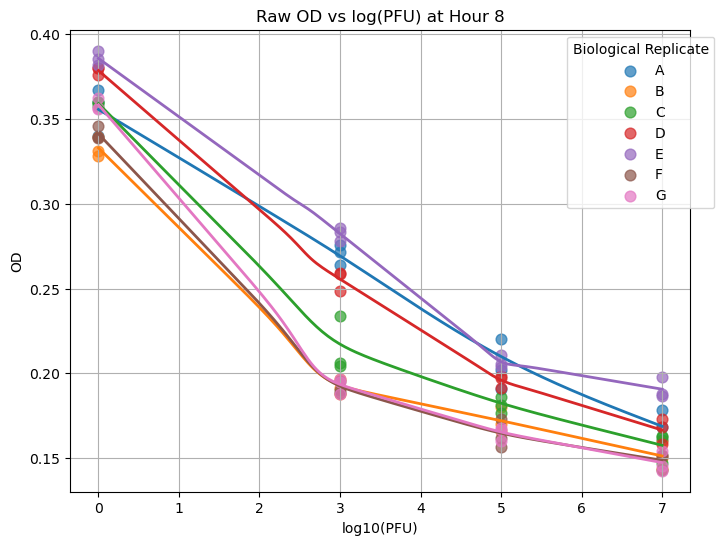

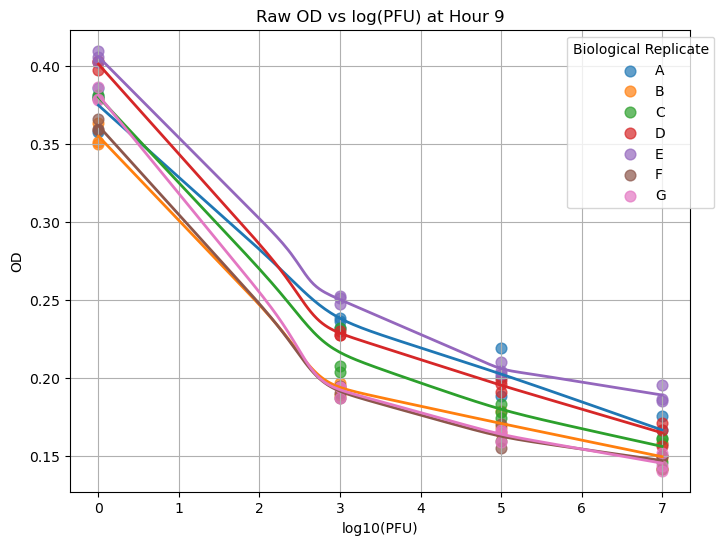

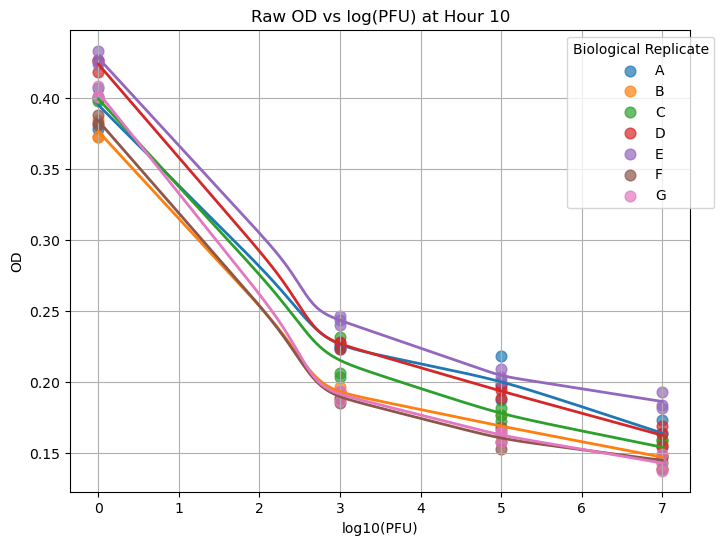

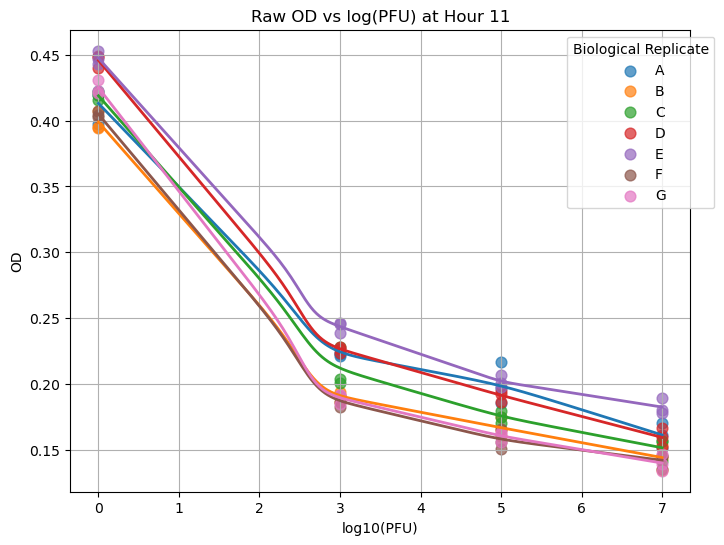

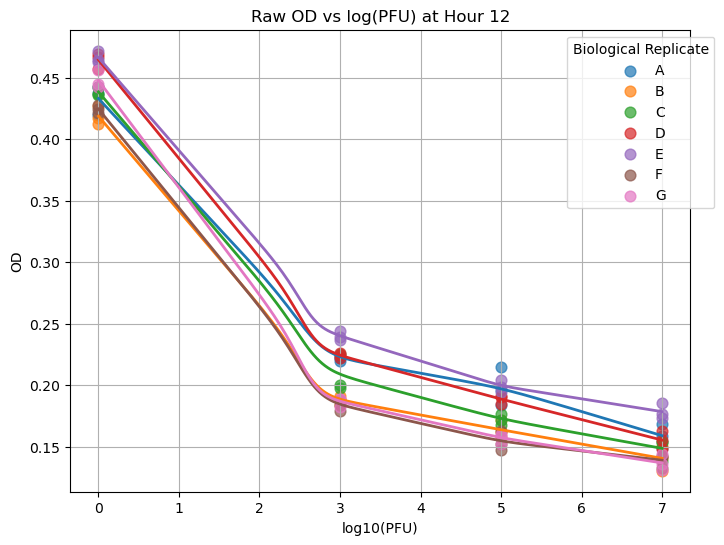

,A,B,C,D,E,F,G
8,3.236181,1.934673,2.110553,2.532663,2.849246,1.934673,1.899497
9,2.251256,1.899497,2.040201,2.040201,2.075377,1.864322,1.864322
10,2.040201,1.864322,1.969849,1.969849,1.969849,1.829146,1.829146
11,1.969849,1.829146,1.934673,1.969849,1.934673,1.793970,1.829146
12,1.934673,1.793970,1.899497,1.934673,1.899497,1.793970,1.793970


In [4]:
df.index = np.round(df.index).astype(int)
df_hourly = df.loc[df.index.isin(range(0, 16))]
df_hourly = df_hourly.groupby(df_hourly.index).first()

x_vals = [0, 3, 5, 7]
bio_reps = list(string.ascii_uppercase)[:7] #A-H

ic50_table = pd.DataFrame(index=range(8,13), columns=bio_reps, dtype=float)

for hour in range(8, 13):
    if hour not in df_hourly.index:
        continue
        
    plt.figure(figsize=(8, 6))

    for letter in bio_reps:
        table = df_hourly.filter(regex = rf'^{letter}')
        if table.empty:
            continue
            
        y_vals = table.loc[hour].values
        
        
        x_repeat = np.repeat(x_vals, 3)
            
        plt.scatter(x_repeat, y_vals, label=letter, s=60, alpha=0.7)
        
       # Fit kernel regression
        kr = KernelReg(endog=y_vals, exog=x_repeat, var_type='c', reg_type='ll')
        
        # Smooth prediction
        x_grid = np.linspace(min(x_repeat), max(x_repeat), 200)
        y_pred_grid, _ = kr.fit(x_grid)
        
        # Half-max from smooth curve
        half_max = (y_pred_grid.max() + y_pred_grid.min()) / 2
        
        # Find IC50
        idx = np.argmin(np.abs(y_pred_grid - half_max))
        ic50 = x_grid[idx]
        
        # Store in table
        ic50_table.loc[hour, letter] = ic50
        
        # Plot smooth curve
        plt.plot(x_grid, y_pred_grid, lw=2)

        
        
    plt.xlabel('log10(PFU)')
    plt.ylabel('OD')
    plt.title(f'Raw OD vs log(PFU) at Hour {hour}')
    plt.legend(title='Biological Replicate', bbox_to_anchor=(1.05, 1))
    plt.grid(True)
    plt.show()
    
ic50_table
        

IC50 val per biol rep

plot all 8 half-max concentrations from the time point as a histogram

In [5]:
#interpolate on continous x axis instead 
x_grid = np.linspace(min(x_repeat), max(x_repeat), 200) #smooth x values
# Predict KernelReg on the grid (smooth)
y_pred_grid, y_std_grid = kr.fit(x_grid)

# Compute half max
half_max = (y_vals.max() + y_vals.min()) / 2
# Compute difference between half max and curve
# Find index of smallest difference
idx = np.argmin(np.abs(y_pred_grid - half_max))
ic50 = x_grid[idx]
ic50

np.float64(1.7587939698492463)

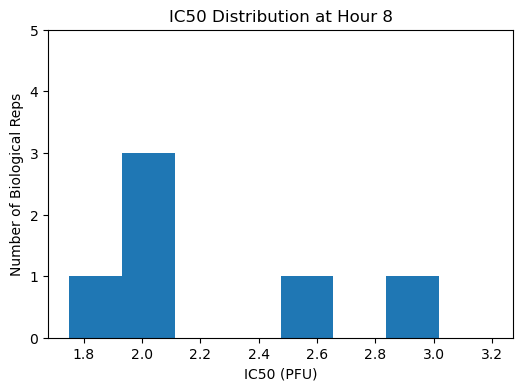

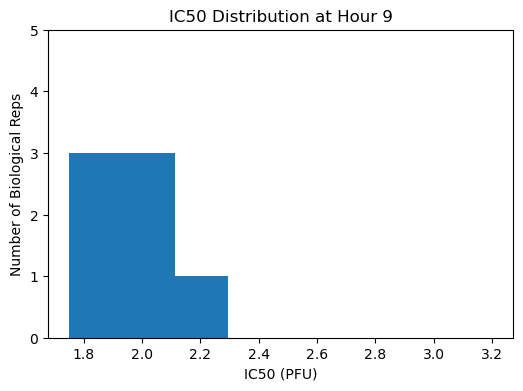

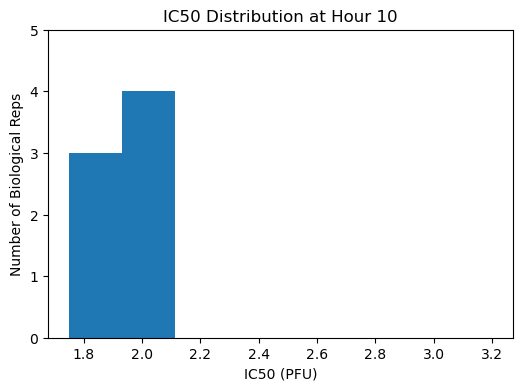

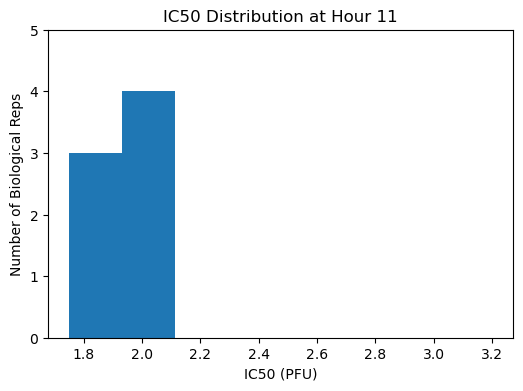

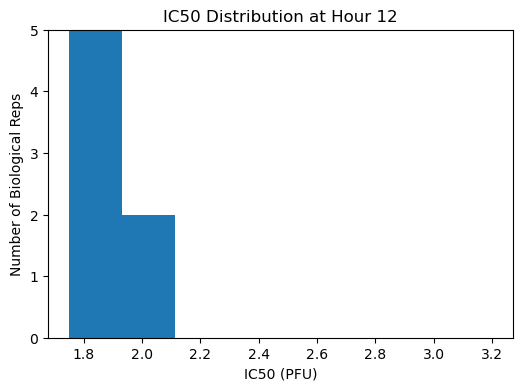

In [6]:
for hour in range(8,13):
    ic50_values = ic50_table.loc[hour].values
    plt.figure(figsize=(6,4))
    plt.hist(ic50_values, bins = 8, range = (1.75, 3.2))
    plt.ylim(0, 5) 
    plt.xlabel('IC50 (PFU)')
    plt.ylabel('Number of Biological Reps')
    plt.title(f'IC50 Distribution at Hour {hour}')

In [10]:
ic50_table

,A,B,C,D,E,F,G
8,3.236181,1.934673,2.110553,2.532663,2.849246,1.934673,1.899497
9,2.251256,1.899497,2.040201,2.040201,2.075377,1.864322,1.864322
10,2.040201,1.864322,1.969849,1.969849,1.969849,1.829146,1.829146
11,1.969849,1.829146,1.934673,1.969849,1.934673,1.793970,1.829146
12,1.934673,1.793970,1.899497,1.934673,1.899497,1.793970,1.793970
